# Setup

**Imports and Configuration**

In [247]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.interpolate import interp1d

# Metric labels for plots
METRIC_LABELS = {
    "mean_belief": "Mean Belief",
    "polarization_var": "Belief Variance (Polarization)",
    "share_extremes": "Share of Extremists",
    "assortativity": "Assortativity (Homophily)",
    "belief_drift": "Mean Belief Drift from Initial",
    "loss_aversion": "Loss Aversion (λ)",
}

**Define File Paths**

In [248]:
SEED = 7777  # Set this to whatever seed you want to analyze
BELIEF_DISTRIBUTION = "trimodal"  # Set this to the belief distribution you want to analyze
# asymmetric_extremists, asymmetric_shift, skewed_positive, trimodal

# File paths - automatically uses seed and belief distribution in filenames
RESULT_FILES = {
    "exp1": f"/content/seed{SEED}_{BELIEF_DISTRIBUTION}_prospect_exp1.csv",
    "exp2": f"/content/seed{SEED}_{BELIEF_DISTRIBUTION}_prospect_exp2.csv",
    "exp3": f"/content/seed{SEED}_{BELIEF_DISTRIBUTION}_prospect_exp3.csv",
    "exp4": f"/content/seed{SEED}_{BELIEF_DISTRIBUTION}_prospect_exp4.csv",
}

regimes = ["mixed", "echo", "curated"]

print(f"Looking for files with seed={SEED}, belief_distribution={BELIEF_DISTRIBUTION}:")
for exp_name, path in RESULT_FILES.items():
    print(f"  {exp_name}: {os.path.basename(path)}")

Looking for files with seed=7777, belief_distribution=trimodal:
  exp1: seed7777_trimodal_prospect_exp1.csv
  exp2: seed7777_trimodal_prospect_exp2.csv
  exp3: seed7777_trimodal_prospect_exp3.csv
  exp4: seed7777_trimodal_prospect_exp4.csv


**Load Data**

In [249]:
data = {}

for exp_name, path in RESULT_FILES.items():
    if not os.path.exists(path):
        print(f"[WARN] Missing file: {path}")
        print(f"       Please upload {os.path.basename(path)} to Google Colab")
        continue

    df = pd.read_csv(path)
    data[exp_name] = df
    print(f"Loaded {exp_name}: {len(df)} rows")

print(f"\nSuccessfully loaded {len(data)}/4 experiment files")

Loaded exp1: 15 rows
Loaded exp2: 3 rows
Loaded exp3: 900 rows
Loaded exp4: 9 rows

Successfully loaded 4/4 experiment files


# Experiment 1

**Define Plotting Function for Experiment 1**

In [250]:
def plot_exp1_loss_aversion(df):
    """Plot loss aversion effects across regimes"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    metrics_to_plot = [
        ("final_polarization", "Final Polarization (Variance)"),
        ("final_extremes", "Final Share of Extremists"),
        ("belief_drift", "Mean Belief Drift"),
        ("final_assortativity", "Final Assortativity"),
    ]

    for ax, (metric, title) in zip(axes, metrics_to_plot):
        if metric not in df.columns:
            ax.text(0.5, 0.5, f"Metric not found:\n{metric}",
                   ha="center", va="center", color="red")
            ax.set_axis_off()
            continue

        for regime in regimes:
            regime_data = df[df["regime"] == regime]
            if len(regime_data) > 0:
                ax.plot(regime_data["loss_aversion"], regime_data[metric],
                       marker='o', linewidth=2, markersize=8, label=regime.capitalize())

        ax.set_xlabel("Loss Aversion (λ)", fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()


    plt.suptitle("Experiment 1: Loss Aversion Effects Across Network Regimes",
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

**Plot Experiment 1**

EXPERIMENT 1: Loss Aversion Effects


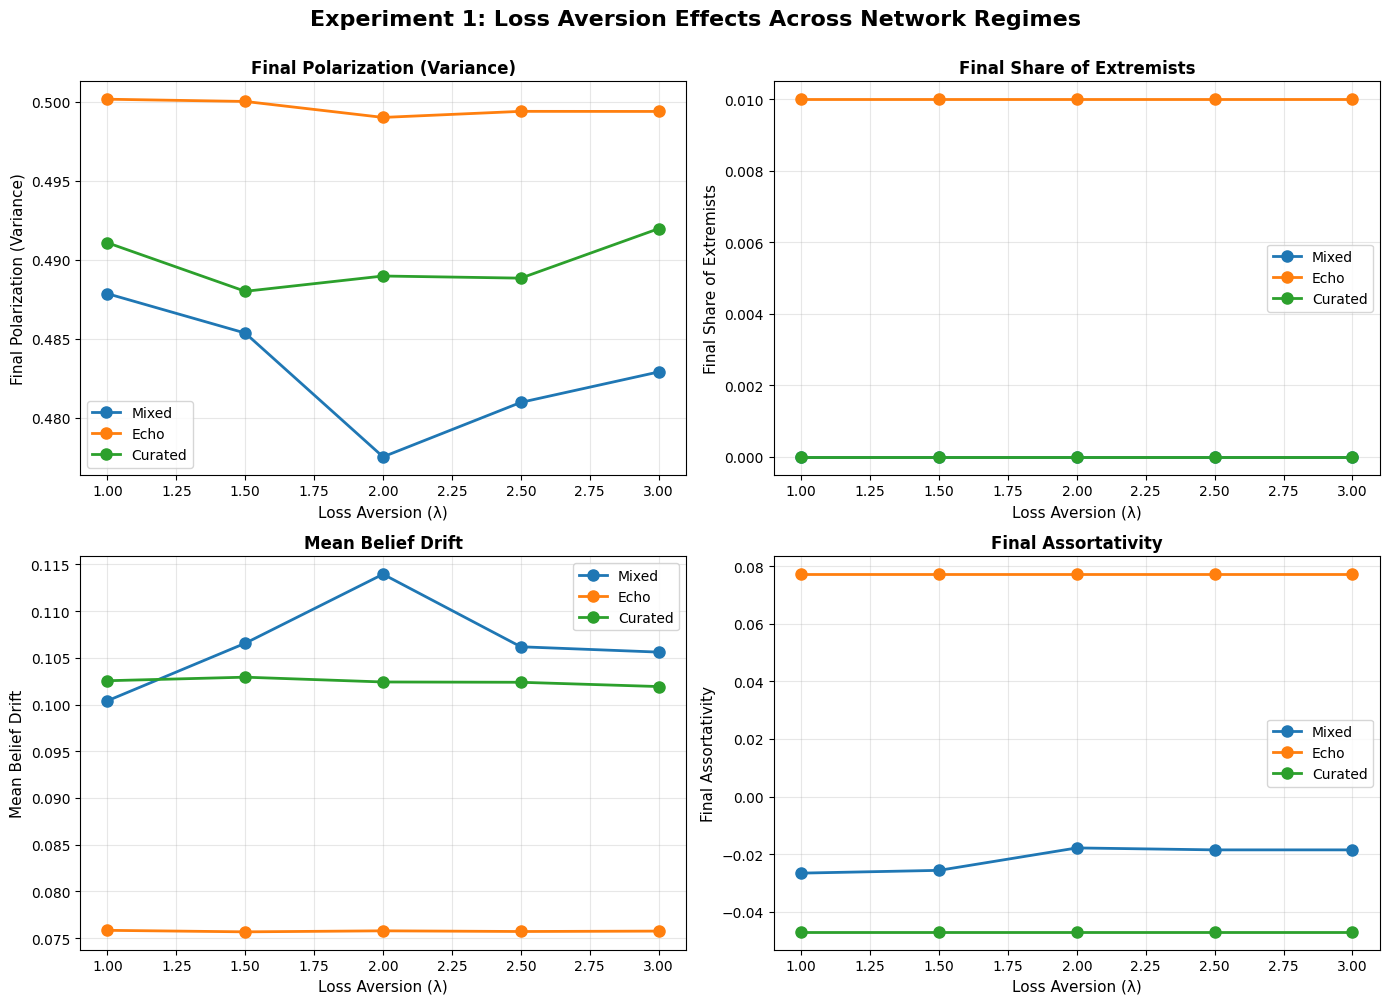

In [251]:
if "exp1" in data:
    print("="*70)
    print("EXPERIMENT 1: Loss Aversion Effects")
    print("="*70)
    plot_exp1_loss_aversion(data["exp1"])
else:
    print("Experiment 1 data not loaded")

# Experiment 2

**Define Plotting Function for Experiment 2**

In [252]:
def plot_exp2_reference_points(df):
    """Plot reference point effects"""

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    metrics_to_plot = [
        ("final_polarization", "Final Polarization"),
        ("belief_drift", "Mean Belief Drift"),
        ("reference_crossing_rate", "Reference Crossing Rate\n(λ=2.0 prevents crossings)"),
    ]

    for ax, (metric, title) in zip(axes, metrics_to_plot):
        if metric not in df.columns:
            ax.text(0.5, 0.5, f"Metric not found:\n{metric}",
                   ha="center", va="center", color="red")
            ax.set_axis_off()
            continue

        values = [df[df["regime"] == r][metric].values[0] if len(df[df["regime"] == r]) > 0 else 0
                 for r in regimes]

        bars = ax.bar(regimes, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'],
                     alpha=0.7, edgecolor='black')

        ax.set_ylabel(title, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10)

        # Add annotation for crossing rate graph
        if metric == "reference_crossing_rate":
            ax.text(0.5, 0.85, "Loss aversion (λ=2.0)\nprevents all crossings",
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=11, style='italic', color='red',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle("Experiment 2: Reference Point Effects - Loss Aversion Prevents Identity Changes",
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

**Plot Experiment 2**

EXPERIMENT 2: Reference Point Effects


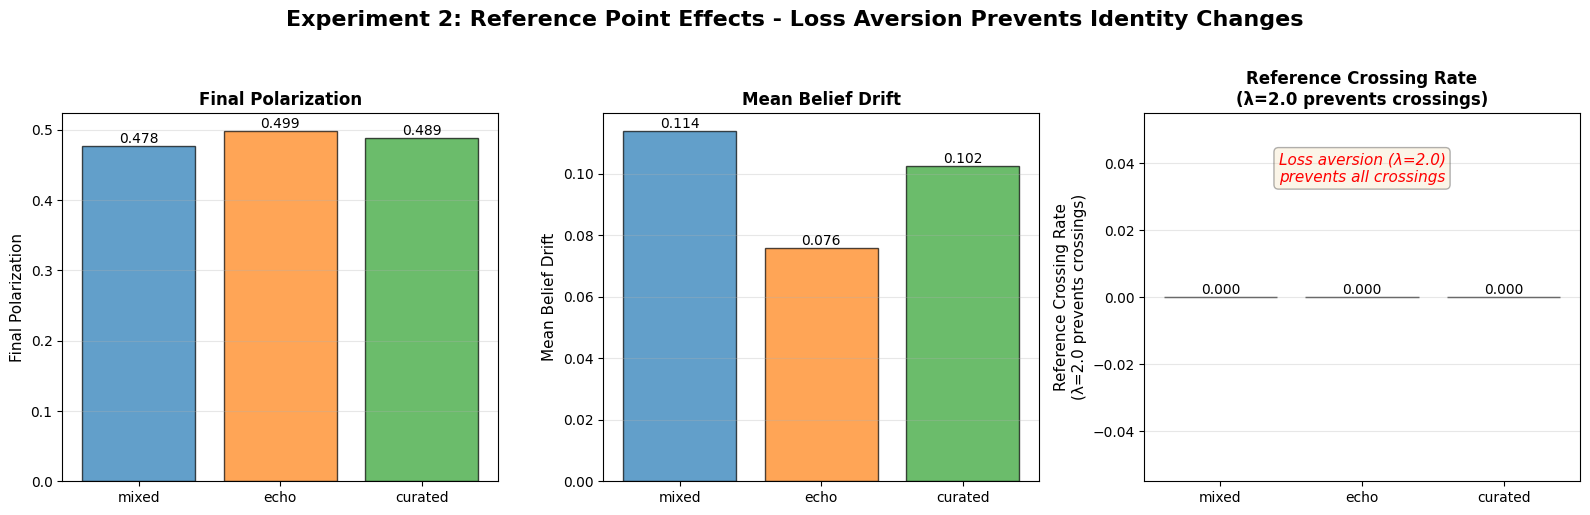

In [253]:
if "exp2" in data:
    print("="*70)
    print("EXPERIMENT 2: Reference Point Effects")
    print("="*70)
    plot_exp2_reference_points(data["exp2"])
else:
    print("Experiment 2 data not loaded")

# Experiment 3

**Define Plotting Function for Experiment 3**

In [254]:
def plot_exp3_regime_comparison(df):
    """Plot network regime comparison over time"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    metrics_to_plot = [
        ("mean_belief", "Mean Belief"),
        ("polarization_var", "Belief Variance (Polarization)"),
        ("share_extremes", "Share of Extremists"),
        ("belief_drift", "Mean Belief Drift"),
    ]

    for ax, (metric, title) in zip(axes, metrics_to_plot):
        if metric not in df.columns:
            ax.text(0.5, 0.5, f"Metric not found:\n{metric}",
                   ha="center", va="center", color="red")
            ax.set_axis_off()
            continue

        for regime in regimes:
            regime_data = df[df["regime"] == regime]
            if len(regime_data) > 0:
                ax.plot(regime_data["step"], regime_data[metric],
                       linewidth=2, label=regime.capitalize())

        ax.set_xlabel("Step", fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle("Experiment 3: Network Regime Comparison Over Time (λ=2.0)",
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

**Plot Experiment 3**

EXPERIMENT 3: Network Regime Comparison


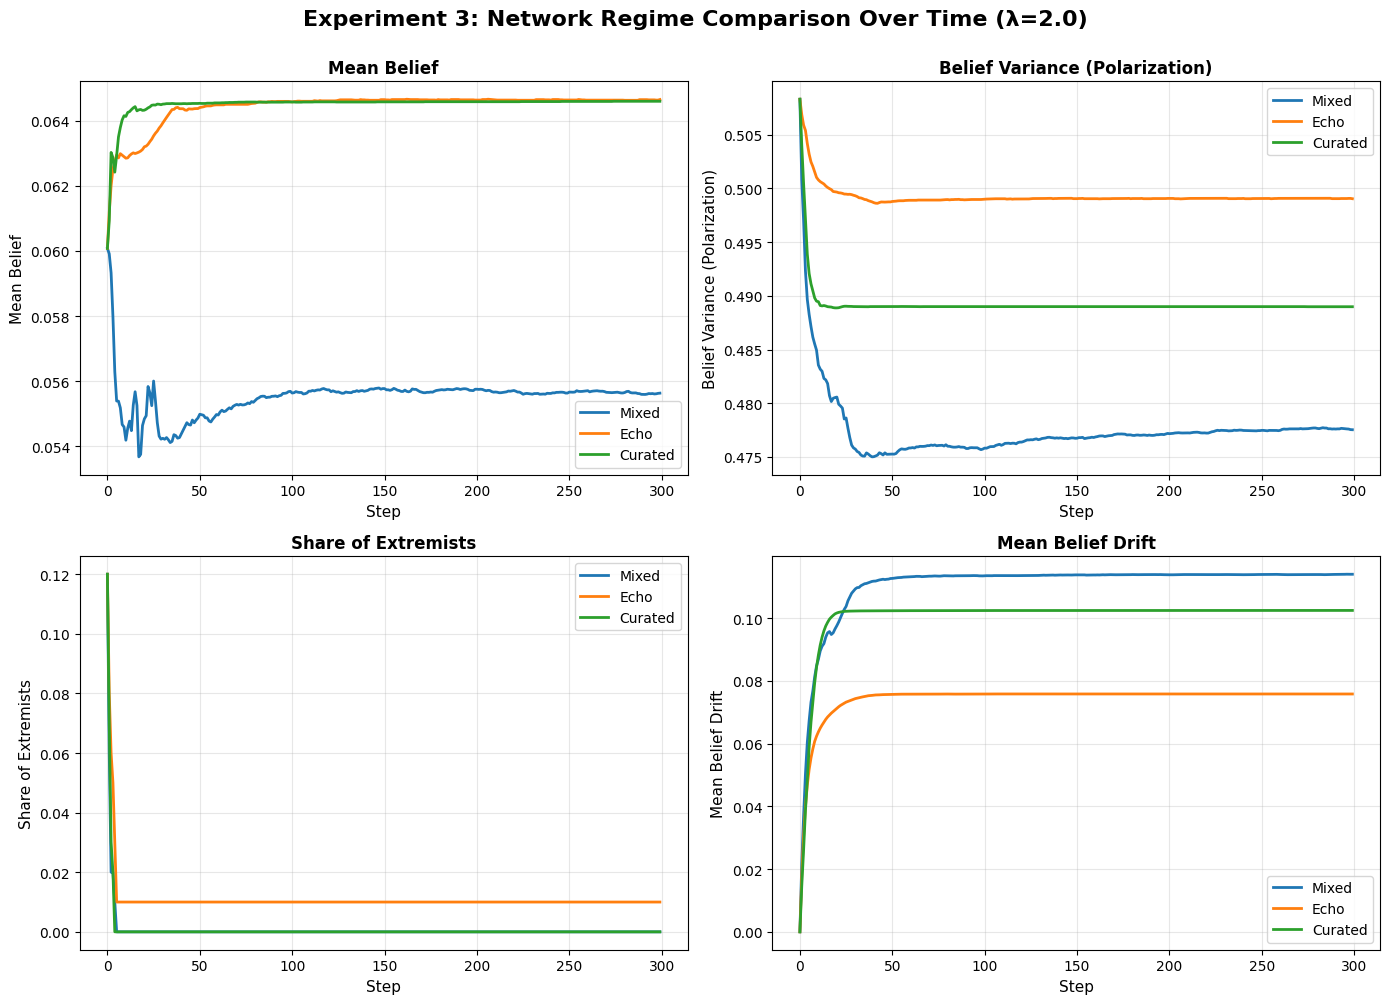

In [255]:
if "exp3" in data:
    print("="*70)
    print("EXPERIMENT 3: Network Regime Comparison")
    print("="*70)
    plot_exp3_regime_comparison(data["exp3"])
else:
    print("Experiment 3 data not loaded")

# Experiment 4

**Define Plotting Functions for Experiment 4**

In [256]:
def plot_exp4_lines(df):
    """Plot interaction line plots with smooth interpolation"""
    from scipy.interpolate import interp1d

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Define colors for consistency
    colors = {0.05: '#1f77b4', 0.15: '#ff7f0e', 0.30: '#2ca02c'}

    for stub_val in sorted(df["stubbornness"].unique()):
        stub_data = df[df["stubbornness"] == stub_val].sort_values("loss_aversion")

        x = stub_data["loss_aversion"].values

        # Interpolate each metric
        for idx, metric in enumerate(["final_polarization", "final_extremes", "belief_drift"]):
            y = stub_data[metric].values

            # Create smooth curve
            f = interp1d(x, y, kind='quadratic')
            x_smooth = np.linspace(x.min(), x.max(), 100)
            y_smooth = f(x_smooth)

            axes[idx].plot(x_smooth, y_smooth, linewidth=2,
                          label=f'Stubbornness={stub_val}',
                          color=colors[stub_val])
            axes[idx].plot(x, y, 'o', markersize=8, color=colors[stub_val])

    axes[0].set_xlabel("Loss Aversion (λ)", fontsize=11)
    axes[0].set_ylabel("Final Polarization", fontsize=11)
    axes[0].set_title("Polarization by Loss Aversion", fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel("Loss Aversion (λ)", fontsize=11)
    axes[1].set_ylabel("Share of Extremists", fontsize=11)
    axes[1].set_title("Extremism by Loss Aversion", fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].set_xlabel("Loss Aversion (λ)", fontsize=11)
    axes[2].set_ylabel("Mean Belief Drift", fontsize=11)
    axes[2].set_title("Belief Drift by Loss Aversion", fontsize=12, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("Interaction Effects: Line Plot View",
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

**Plot Experiment 4**

EXPERIMENT 4: Loss Aversion × Stubbornness Interaction


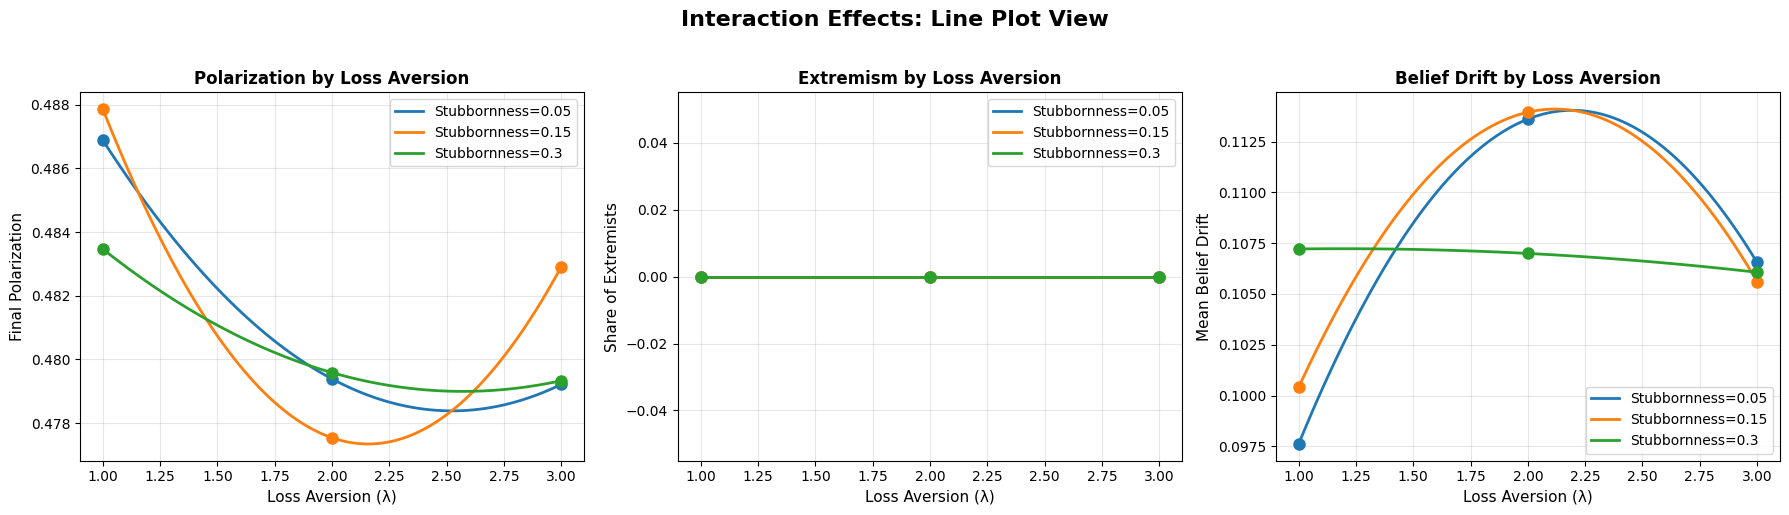

In [257]:
if "exp4" in data:
    print("="*70)
    print("EXPERIMENT 4: Loss Aversion × Stubbornness Interaction")
    print("="*70)
    plot_exp4_lines(data["exp4"])
else:
    print("Experiment 4 data not loaded")